# Question ↔ Answer Retrieval Benchmark of Multilingual Embedding Models

1,000 random question–answer pairs from [`ytu-ce-cosmos/gsm8k_tr`](https://huggingface.co/datasets/ytu-ce-cosmos/gsm8k_tr) (Turkish GSM8K math word problems). For every model we embed questions and answers, rank candidates by **angular distance** and measure Top-1 / Top-5 success in both directions (question → answer and answer → question).

In [31]:
import torch
import random
import time
import gc
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import os
import json

In [29]:
# Checkpoint folder
checkpoint_dir = "embedding_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [1]:
# Dataset
dataset = load_dataset("ytu-ce-cosmos/gsm8k_tr")
indices = random.sample(range(len(dataset['train'])), 1000)
questions = [dataset['train']['question'][i] for i in indices]
answers = [dataset['train']['answer'][i] for i in indices]

In [39]:
# Modeller
model_names = [
    "intfloat/multilingual-e5-base",
    "sentence-transformers/LaBSE",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "BAAI/bge-m3",
    "sentence-transformers/static-similarity-mrl-multilingual-v1",
    "ytu-ce-cosmos/turkish-colbert"
]

> The sampled 1,000 pairs were saved once and are re-loaded here so that every model is evaluated on the same set.

In [33]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('questions_and_answers.csv')

# Take the 'question' and 'answer' columns
questions = df['Soru'].tolist()
answers = df['Cevap'].tolist()

## Helper functions: embeddings, angular similarity, Top-k success

In [35]:
# Embedding function
def get_embeddings(texts, tokenizer, model):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).numpy()
    
# Top-k success rate
def calculate_top_k_success_rate(top_k_indices, true_indices, k=5):
    correct = np.any(top_k_indices == true_indices[:, None], axis=1)
    top_1_success = np.mean(top_k_indices[:, -1] == true_indices)
    top_5_success = np.mean(correct)
    return top_1_success, top_5_success

# Angular similarity function (angle in radians)
def angular_distance(u, v):
    cos_sim = cosine_similarity(u, v)
    clipped = np.clip(cos_sim, -1.0, 1.0)
    angles = np.arccos(clipped)
    return -angles  # smaller angle means more similar, so sort by negative values

# Top-k by angular similarity
def get_top_k_similar(query_embeddings, embeddings, k=5):
    similarity = angular_distance(query_embeddings, embeddings)
    top_k_indices = np.argsort(similarity, axis=1)[:, -k:]
    return top_k_indices

## Compute and cache embeddings for each model

In [10]:
# Only compute and save embeddings
def process_model(model_name, questions, answers):
    print(f"Computing embeddings: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    start_time = time.time()
    question_embeddings = get_embeddings(questions, tokenizer, model)
    answer_embeddings = get_embeddings(answers, tokenizer, model)
    end_time = time.time()

    embedding_time = end_time - start_time

    torch.save({
        'question_embeddings': question_embeddings,
        'answer_embeddings': answer_embeddings,
        'embedding_time': embedding_time
    }, f"{checkpoint_dir}/{model_name.replace('/', '_')}_embeddings.pth")

    print(f"{model_name}: embeddings done. Time: {embedding_time:.2f} s")

    del model
    del tokenizer
    del question_embeddings
    del answer_embeddings
    gc.collect()
    torch.cuda.empty_cache()

In [19]:
for model in model_names:
    process_model(model, questions, answers)

Computing embeddings: sentence-transformers/static-similarity-mrl-multilingual-v1


In [37]:
def process_sentence_transformer_model(model_name, questions, answers):
    print(f"SentenceTransformer modeli embed ediliyor: {model_name}")
    model = SentenceTransformer(model_name)

    start_time = time.time()
    question_embeddings = get_sentence_transformer_embeddings(questions, model)
    answer_embeddings = get_sentence_transformer_embeddings(answers, model)
    end_time = time.time()

    embedding_time = end_time - start_time

    torch.save({
        'question_embeddings': question_embeddings,
        'answer_embeddings': answer_embeddings,
        'embedding_time': embedding_time
    }, f"{checkpoint_dir}/{model_name.replace('/', '_')}_embeddings.pth")

    print(f"{model_name} done. Time: {embedding_time:.2f} s")

    del model
    del question_embeddings
    del answer_embeddings
    gc.collect()
    torch.cuda.empty_cache()

def get_sentence_transformer_embeddings(texts, model):
    return model.encode(texts, convert_to_numpy=True, show_progress_bar=False)

sentence_transformer_model = "sentence-transformers/static-similarity-mrl-multilingual-v1"
process_sentence_transformer_model(sentence_transformer_model, questions, answers)

SentenceTransformer modeli embed ediliyor: sentence-transformers/static-similarity-mrl-multilingual-v1
sentence-transformers/static-similarity-mrl-multilingual-v1 done. Time: 0.21 s


In [13]:
# Results
results = {}

# Per-model processing
top_k = 5
for model_name in model_names:
    print(f"Processing model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    start_time = time.time()
    question_embeddings = get_embeddings(questions, tokenizer, model)
    answer_embeddings = get_embeddings(answers, tokenizer, model)
    end_time = time.time()

    embedding_time = end_time - start_time

    question_to_answer_top_5 = get_top_k_similar(question_embeddings, answer_embeddings, k=top_k)
    answer_to_question_top_5 = get_top_k_similar(answer_embeddings, question_embeddings, k=top_k)

    top_1_q2a, top_5_q2a = calculate_top_k_success_rate(question_to_answer_top_5, np.arange(1000), k=top_k)
    top_1_a2q, top_5_a2q = calculate_top_k_success_rate(answer_to_question_top_5, np.arange(1000), k=top_k)

    # Save
    torch.save({
        'question_embeddings': question_embeddings,
        'answer_embeddings': answer_embeddings,
        'embedding_time': embedding_time
    }, f"{checkpoint_dir}/{model_name.replace('/', '_')}_embeddings.pth")

    results[model_name] = {
        'top_1_q2a': float(top_1_q2a),
        'top_5_q2a': float(top_5_q2a),
        'top_1_a2q': float(top_1_a2q),
        'top_5_a2q': float(top_5_a2q),
        'embedding_time': float(embedding_time)
    }

    # Free RAM
    del model
    del tokenizer
    del question_embeddings
    del answer_embeddings
    gc.collect()
    torch.cuda.empty_cache()

Processing model: intfloat/multilingual-e5-base


In [ ]:
# Save results as JSON
with open("model_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("All models processed and saved.")

## Evaluate all models from the cached embeddings

In [51]:
import torch
import os

checkpoint_dir = "embedding_checkpoints"
files = os.listdir(checkpoint_dir)

for file in files:
    if file.endswith(".pth"):
        path = os.path.join(checkpoint_dir, file)
        data = torch.load(path)

        print(f"--- {file} ---")
        print(f"question_embeddings shape: {data['question_embeddings'].shape}")
        print(f"answer_embeddings shape:   {data['answer_embeddings'].shape}")
        print(f"embedding_time:            {data['embedding_time']:.2f} s")
        print()


--- BAAI_bge-m3_embeddings.pth ---
question_embeddings shape: (1000, 1024)
answer_embeddings shape:   (1000, 1024)
embedding_time:            1166.47 s

--- HIT-TMG_KaLM-embedding-multilingual-mini-instruct-v1_embeddings.pth ---
question_embeddings shape: (1000, 896)
answer_embeddings shape:   (1000, 896)
embedding_time:            3125.16 s

--- intfloat_multilingual-e5-base_embeddings.pth ---
question_embeddings shape: (1000, 768)
answer_embeddings shape:   (1000, 768)
embedding_time:            355.95 s

--- sentence-transformers_LaBSE_embeddings.pth ---
question_embeddings shape: (1000, 768)
answer_embeddings shape:   (1000, 768)
embedding_time:            316.58 s

--- sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pth ---
question_embeddings shape: (1000, 384)
answer_embeddings shape:   (1000, 384)
embedding_time:            118.05 s

--- sentence-transformers_static-similarity-mrl-multilingual-v1_embeddings.pth ---
question_embeddings shape: (1000, 1024)


In [53]:
import os
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import json

# Angular similarity function (cosine to angle)
def angular_distance(u, v):
    cos_sim = cosine_similarity(u, v)
    clipped = np.clip(cos_sim, -1.0, 1.0)
    angles = np.arccos(clipped)
    return -angles  # Smaller angle means more similar

# Top-k similarity
def get_top_k_similar(query_embeddings, embeddings, k=5):
    similarity = angular_distance(query_embeddings, embeddings)
    top_k_indices = np.argsort(similarity, axis=1)[:, -k:]
    return top_k_indices

# Top-k success rate

def calculate_top_k_success_rate(top_k_indices, true_indices, k=5):
    correct = np.any(top_k_indices == true_indices[:, None], axis=1)
    top_1_success = np.mean(top_k_indices[:, -1] == true_indices)
    top_5_success = np.mean(correct)
    return top_1_success, top_5_success

# t-SNE plot

def plot_tsne(question_embeddings, answer_embeddings, model_name):
    embeddings = np.concatenate((question_embeddings, answer_embeddings), axis=0)
    labels = ["Soru"] * len(question_embeddings) + ["Cevap"] * len(answer_embeddings)

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette="Set1", s=50, alpha=0.7)
    plt.title(f"t-SNE - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"tsne_plots/{model_name.replace('/', '_')}_tsne.png")
    plt.close()

# Evaluation
def evaluate_model(embedding_path, model_name):
    data = torch.load(embedding_path)
    q_embeds = data["question_embeddings"]
    a_embeds = data["answer_embeddings"]
    time_taken = data["embedding_time"]

    top_k = 5
    q2a = get_top_k_similar(q_embeds, a_embeds, k=top_k)
    a2q = get_top_k_similar(a_embeds, q_embeds, k=top_k)

    top1_q2a, top5_q2a = calculate_top_k_success_rate(q2a, np.arange(len(q_embeds)), k=top_k)
    top1_a2q, top5_a2q = calculate_top_k_success_rate(a2q, np.arange(len(q_embeds)), k=top_k)

    print(f"Model: {model_name}")
    print(f"Top-1 Q -> A: {top1_q2a*100:.2f}%")
    print(f"Top-5 Q -> A: {top5_q2a*100:.2f}%")
    print(f"Top-1 A -> Q: {top1_a2q*100:.2f}%")
    print(f"Top-5 A -> Q: {top5_a2q*100:.2f}%")
    print(f"Embedding time: {time_taken:.2f} s\n")

    return {
        "model": model_name,
        "top1_q2a": top1_q2a,
        "top5_q2a": top5_q2a,
        "top1_a2q": top1_a2q,
        "top5_a2q": top5_a2q,
        "time": time_taken
    }, q_embeds, a_embeds


# Main loop
os.makedirs("tsne_plots", exist_ok=True)
results = []
checkpoint_dir = "embedding_checkpoints"
for file in os.listdir(checkpoint_dir):
    if file.endswith(".pth"):
        path = os.path.join(checkpoint_dir, file)
        model_name = file.replace("_embeddings.pth", "").replace("_", "/", 1)
        result, q, a = evaluate_model(path, model_name)
        results.append(result)
        plot_tsne(q, a, model_name)

Model: BAAI/bge-m3
Top-1 Q -> A: 94.70%
Top-5 Q -> A: 98.10%
Top-1 A -> Q: 97.10%
Top-5 A -> Q: 98.50%
Embedding time: 1166.47 s



Model: HIT-TMG/KaLM-embedding-multilingual-mini-instruct-v1
Top-1 Q -> A: 77.20%
Top-5 Q -> A: 79.60%
Top-1 A -> Q: 67.30%
Top-5 A -> Q: 70.70%
Embedding time: 3125.16 s



Model: intfloat/multilingual-e5-base
Top-1 Q -> A: 94.30%
Top-5 Q -> A: 96.90%
Top-1 A -> Q: 96.10%
Top-5 A -> Q: 98.40%
Embedding time: 355.95 s



Model: sentence-transformers/LaBSE
Top-1 Q -> A: 91.30%
Top-5 Q -> A: 95.00%
Top-1 A -> Q: 95.00%
Top-5 A -> Q: 97.20%
Embedding time: 316.58 s



Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Top-1 Q -> A: 89.00%
Top-5 Q -> A: 95.90%
Top-1 A -> Q: 88.30%
Top-5 A -> Q: 95.00%
Embedding time: 118.05 s



Model: sentence-transformers/static-similarity-mrl-multilingual-v1
Top-1 Q -> A: 93.30%
Top-5 Q -> A: 97.20%
Top-1 A -> Q: 88.10%
Top-5 A -> Q: 95.10%
Embedding time: 0.21 s



Model: ytu-ce-cosmos/turkish-colbert
Top-1 Q -> A: 79.20%
Top-5 Q -> A: 91.20%
Top-1 A -> Q: 82.60%
Top-5 A -> Q: 93.00%
Embedding time: 276.38 s



In [55]:
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("All models evaluated and plots saved.")

All models evaluated and plots saved.


## Results


--- RESULTS TABLE ---


,model,top1_q2a,top5_q2a,top1_a2q,top5_a2q,time
0,BAAI/bge-m3,0.947,0.981,0.971,0.985,1166.466374
1,HIT-TMG/KaLM-embedding-multilingual-mini-instr...,0.772,0.796,0.673,0.707,3125.159299
2,intfloat/multilingual-e5-base,0.943,0.969,0.961,0.984,355.951134
3,sentence-transformers/LaBSE,0.913,0.950,0.950,0.972,316.577273
4,sentence-transformers/paraphrase-multilingual-...,0.890,0.959,0.883,0.950,118.050212
5,sentence-transformers/static-similarity-mrl-mu...,0.933,0.972,0.881,0.951,0.207511
6,ytu-ce-cosmos/turkish-colbert,0.792,0.912,0.826,0.930,276.377258


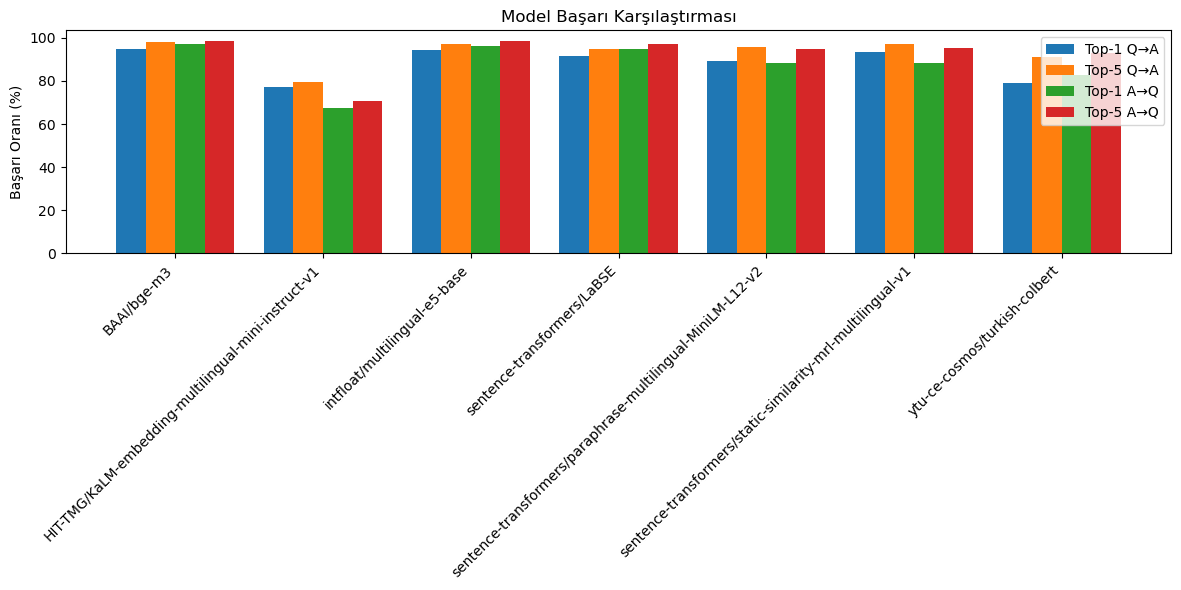

All models evaluated; table and chart created.


In [61]:
# Show as table
print("\n--- RESULTS TABLE ---")
df = pd.DataFrame(results)
display(df[["model", "top1_q2a", "top5_q2a", "top1_a2q", "top5_a2q", "time"]])

# Show as bar chart
plt.figure(figsize=(12, 6))
bar_width = 0.2
x = np.arange(len(df))

plt.bar(x - 1.5*bar_width, df["top1_q2a"] * 100, width=bar_width, label="Top-1 Q→A")
plt.bar(x - 0.5*bar_width, df["top5_q2a"] * 100, width=bar_width, label="Top-5 Q→A")
plt.bar(x + 0.5*bar_width, df["top1_a2q"] * 100, width=bar_width, label="Top-1 A→Q")
plt.bar(x + 1.5*bar_width, df["top5_a2q"] * 100, width=bar_width, label="Top-5 A→Q")

plt.xticks(x, df["model"], rotation=45, ha="right")
plt.ylabel("Başarı Oranı (%)")
plt.title("Model Başarı Karşılaştırması")
plt.legend()
plt.tight_layout()
plt.savefig("barplot_model_accuracy.png")
plt.show()

print("All models evaluated; table and chart created.")


--- RESULTS TABLE ---


,model,top1_q2a,top5_q2a,top1_a2q,top5_a2q,time
0,BAAI/bge-m3,0.947,0.981,0.971,0.985,1166.466374
1,HIT-TMG/KaLM-embedding-multilingual-mini-instr...,0.772,0.796,0.673,0.707,3125.159299
2,intfloat/multilingual-e5-base,0.943,0.969,0.961,0.984,355.951134
3,sentence-transformers/LaBSE,0.913,0.950,0.950,0.972,316.577273
4,sentence-transformers/paraphrase-multilingual-...,0.890,0.959,0.883,0.950,118.050212
5,sentence-transformers/static-similarity-mrl-mu...,0.933,0.972,0.881,0.951,0.207511
6,ytu-ce-cosmos/turkish-colbert,0.792,0.912,0.826,0.930,276.377258


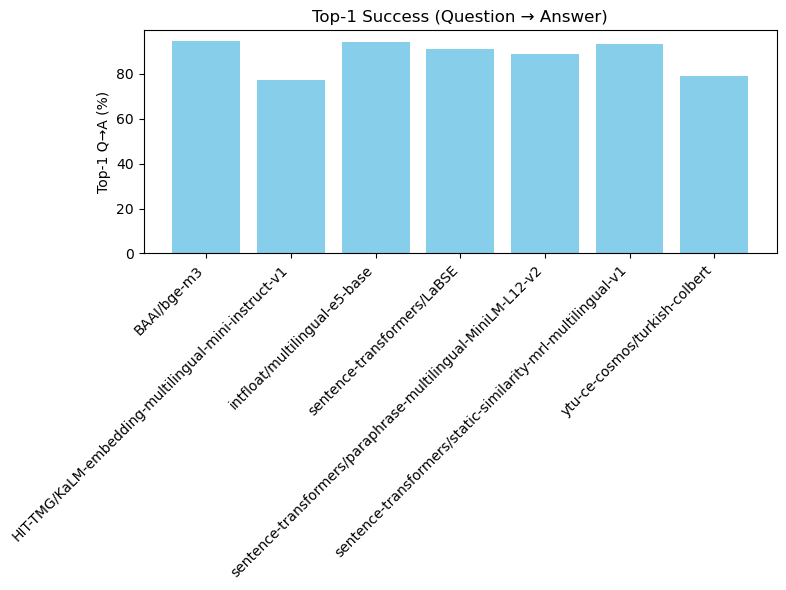

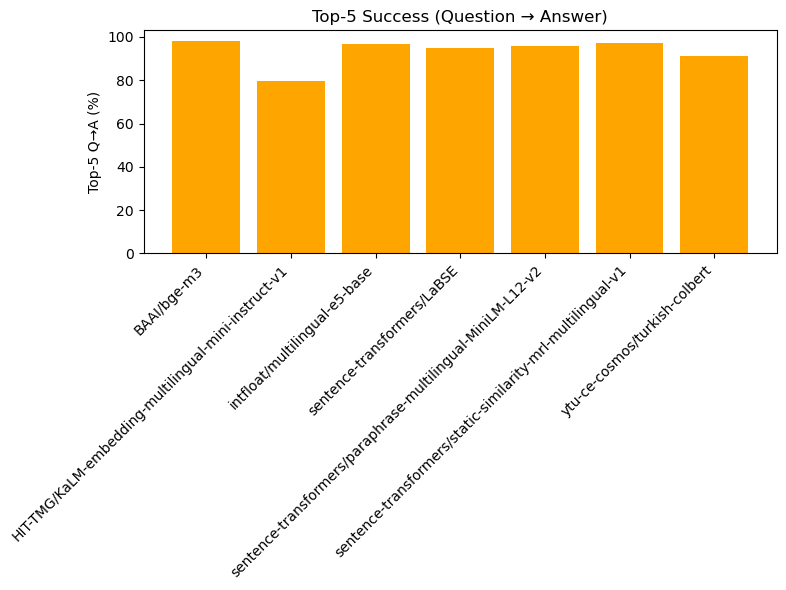

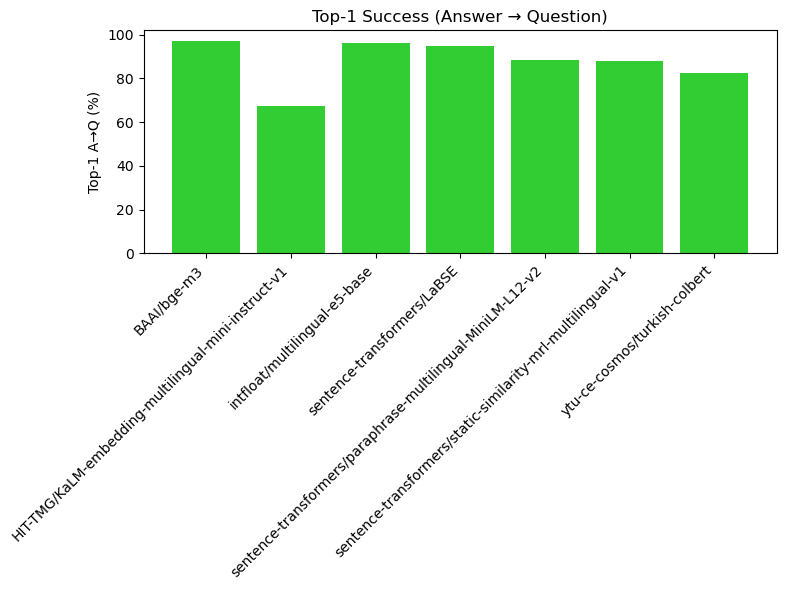

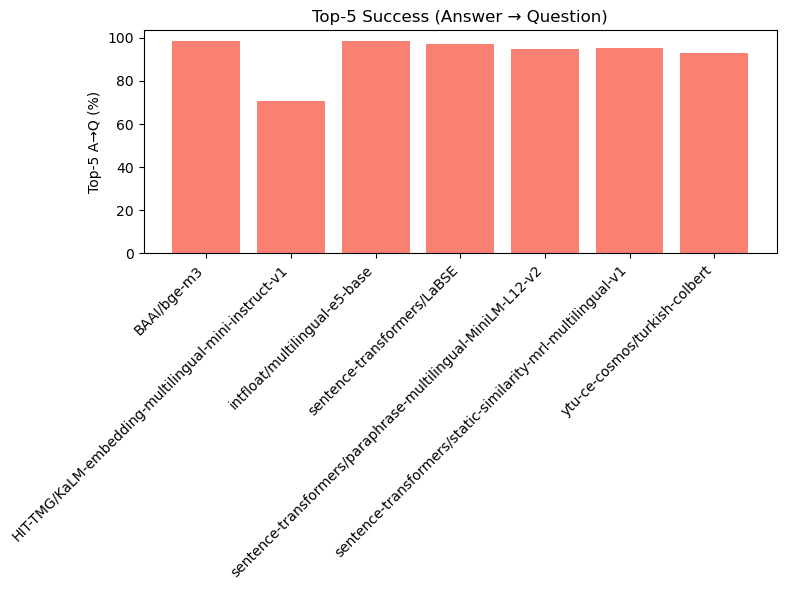

All models evaluated; table and all charts created.


In [109]:
# Show as table
print("\n--- RESULTS TABLE ---")
df = pd.DataFrame(results)
display(df[["model", "top1_q2a", "top5_q2a", "top1_a2q", "top5_a2q", "time"]])

# 4 separate plots
plt.figure(figsize=(8, 6))
plt.bar(df['model'], df['top1_q2a'] * 100, color='skyblue')
plt.ylabel("Top-1 Q→A (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-1 Success (Question → Answer)")
plt.tight_layout()
plt.savefig("barplot_top1_q2a.png")
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(df['model'], df['top5_q2a'] * 100, color='orange')
plt.ylabel("Top-5 Q→A (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-5 Success (Question → Answer)")
plt.tight_layout()
plt.savefig("barplot_top5_q2a.png")
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(df['model'], df['top1_a2q'] * 100, color='limegreen')
plt.ylabel("Top-1 A→Q (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-1 Success (Answer → Question)")
plt.tight_layout()
plt.savefig("barplot_top1_a2q.png")
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(df['model'], df['top5_a2q'] * 100, color='salmon')
plt.ylabel("Top-5 A→Q (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-5 Success (Answer → Question)")
plt.tight_layout()
plt.savefig("barplot_top5_a2q.png")
plt.show()

print("All models evaluated; table and all charts created.")

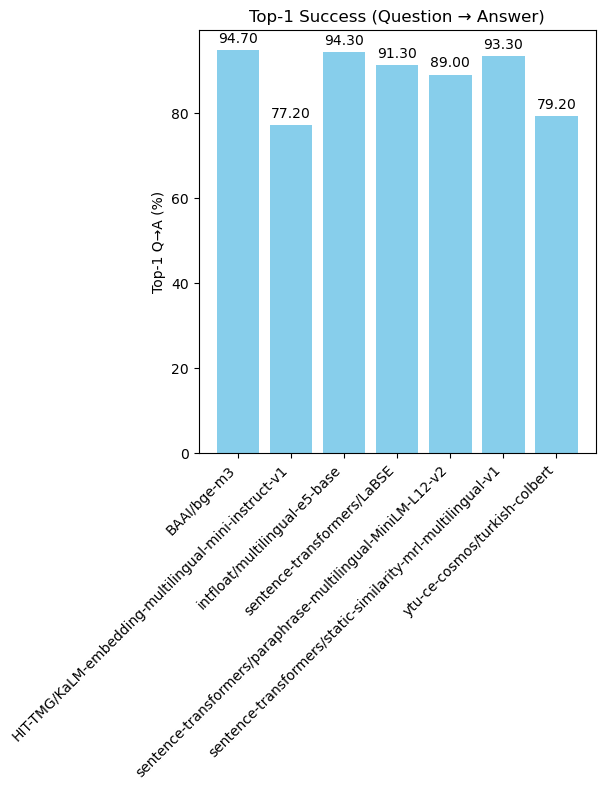

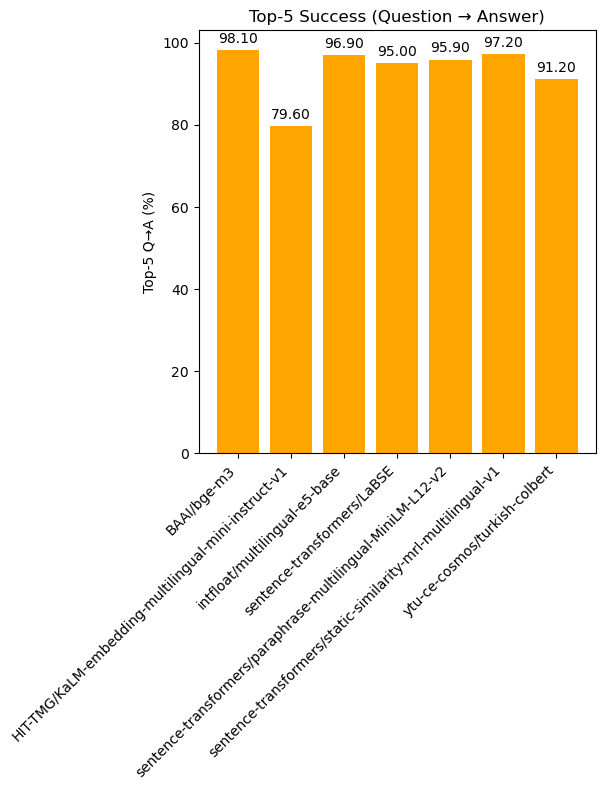

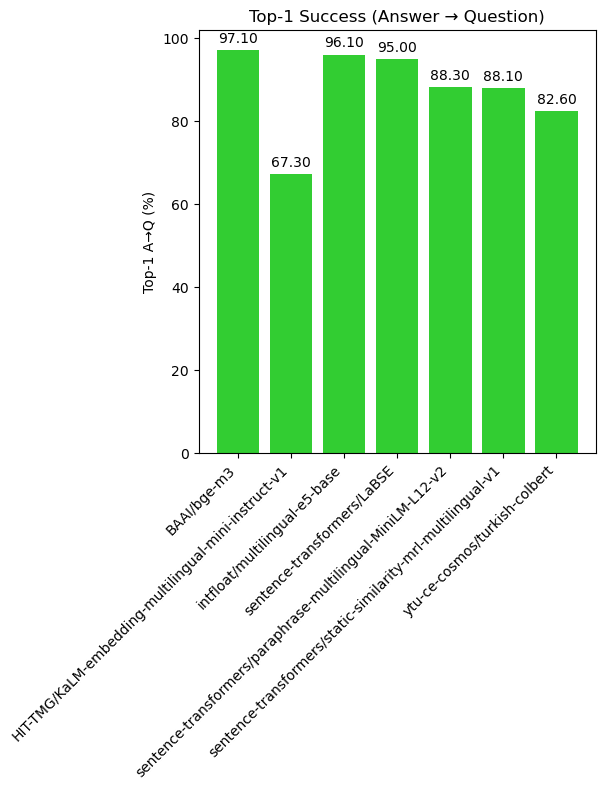

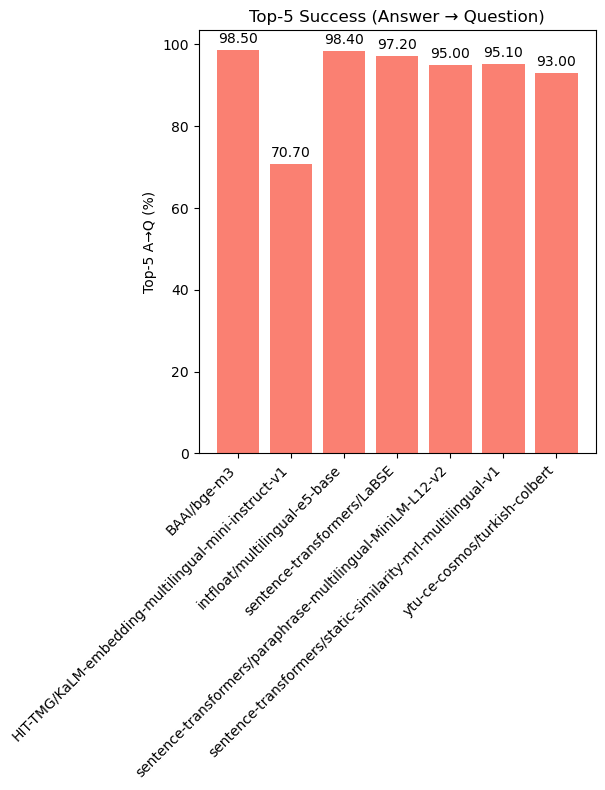

In [119]:
# Write values on top of bars in accuracy plots
plt.figure(figsize=(6, 8))
bars = plt.bar(df['model'], df['top1_q2a'] * 100, color='skyblue')
plt.ylabel("Top-1 Q→A (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-1 Success (Question → Answer)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("barplot_top1_q2a.png")
plt.show()

plt.figure(figsize=(6, 8))
bars = plt.bar(df['model'], df['top5_q2a'] * 100, color='orange')
plt.ylabel("Top-5 Q→A (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-5 Success (Question → Answer)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("barplot_top5_q2a.png")
plt.show()

plt.figure(figsize=(6, 8))
bars = plt.bar(df['model'], df['top1_a2q'] * 100, color='limegreen')
plt.ylabel("Top-1 A→Q (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-1 Success (Answer → Question)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("barplot_top1_a2q.png")
plt.show()

plt.figure(figsize=(6, 8))
bars = plt.bar(df['model'], df['top5_a2q'] * 100, color='salmon')
plt.ylabel("Top-5 A→Q (%)")
plt.xticks(rotation=45, ha="right")
plt.title("Top-5 Success (Answer → Question)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("barplot_top5_a2q.png")
plt.show()


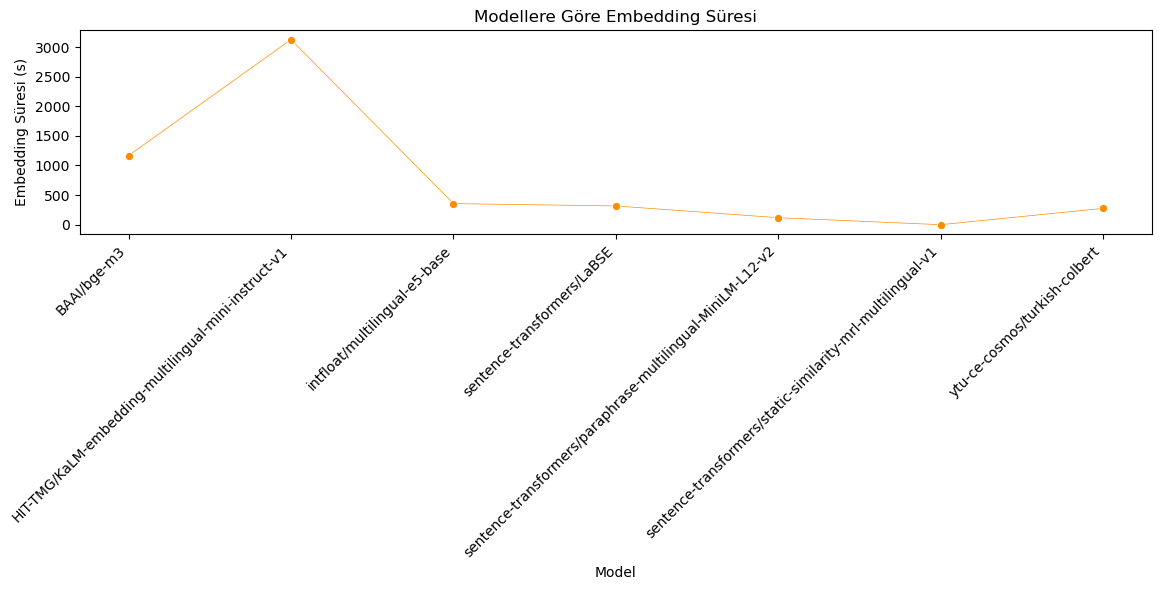

In [103]:
# Embedding time (line + marker plot)
plt.figure(figsize=(12, 6))
sns.lineplot(x="model", y="time", data=df, marker="o", markersize=6, linewidth=0.5, color="darkorange")
plt.ylabel("Embedding Süresi (s)")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.title("Modellere Göre Embedding Süresi")
plt.tight_layout()
plt.savefig("lineplot_embedding_times.png")
plt.show()
